## Harmonized Landsat Sentinel test

In [22]:
import os

os.environ["PROJ_LIB"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["PROJ_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["GDAL_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/gdal"

In [23]:
import teledetection # old : import dinamis_sdk
from pystac_client import Client
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from path import Path
import pystac_client
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
from path import Path
#import pystac_client
import stackstac
import time
import planetary_computer as pc
#from simplestac.utils import ItemCollection, apply_formula, drop_assets_without_proj

In [24]:
from odc.stac import load as load_odc

In [25]:
import warnings
from rasterio import logging

In [26]:
from pyproj import CRS

print(CRS.from_epsg(2154))

EPSG:2154


In [27]:
gdf = gpd.read_file("../data/RNN_limite_poly_l93.shp")

gdf = gdf.set_crs("EPSG:2154")

gdf = gdf.to_crs("EPSG:4326")


gdf2 = gpd.read_file("../data/limite_RI_wgs84.shp")
gdf2 = gdf2.set_crs("EPSG:4326")

In [28]:
#virer les warnings de rasterio
warnings.filterwarnings("ignore")
log = logging.getLogger()
log.setLevel(logging.ERROR)

In [29]:
# Load the area of interest
roi_file = "../data/emprise_massane.geojson"
# Lire le fichier GeoJSON
#roi = gpd.read_file(roi_file)
#print(roi.total_bounds)
roi = gdf
print(roi.crs)

EPSG:4326


In [30]:
catalog = Client.open(
    "https://cmr.earthdata.nasa.gov/stac/LPCLOUD"
)

In [31]:
search = catalog.search(
    collections=["HLSS30.v2.0"],
    bbox=roi.to_crs(4326).total_bounds,
    datetime="2024-01-01/2024-06-30"
)

items = list(search.items())

In [34]:
arr = stackstac.stack(
    items,
    assets=["B02", "B03", "B04", "B8A"],
    epsg=32631,
    resolution=30,
    bounds=tuple(roi.to_crs(32631).total_bounds)
)

In [36]:
print(arr)

<xarray.DataArray 'stackstac-eb0cefceabdfe0444f7dc3b2124a932a' (time: 64,
                                                                band: 4,
                                                                y: 119, x: 117)> Size: 29MB
dask.array<fetch_raster_window, shape=(64, 4, 119, 117), dtype=float64, chunksize=(1, 1, 119, 117), chunktype=numpy.ndarray>
Coordinates:
  * time             (time) datetime64[us] 512B 2024-01-07T10:49:04.637000 .....
    id               (time) <U34 9kB 'HLS.S30.T31TEH.2024007T104431.v2.0' ......
    end_datetime     (time) <U24 6kB '2024-01-07T10:49:04.637Z' ... '2024-06-...
    eo:cloud_cover   (time) int64 512B 50 71 3 17 41 70 18 ... 98 99 30 19 79 94
    start_datetime   (time) <U24 6kB '2024-01-07T10:49:04.637Z' ... '2024-06-...
  * band             (band) <U3 48B 'B02' 'B03' 'B04' 'B8A'
  * y                (y) float64 952B 4.705e+06 4.705e+06 ... 4.702e+06
  * x                (x) float64 936B 4.998e+05 4.999e+05 ... 5.033e+05
    storage:sc

In [38]:
rgb = arr.sel(
    band=["B04", "B03", "B02"]
).isel(time=0)

rgb = rgb.transpose("y", "x", "band")

RuntimeError: Error opening 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T31TEH.2024007T104431.v2.0/HLS.S30.T31TEH.2024007T104431.v2.0.B04.tif': RasterioIOError("'/vsicurl/https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T31TEH.2024007T104431.v2.0/HLS.S30.T31TEH.2024007T104431.v2.0.B04.tif' not recognized as being in a supported file format.")

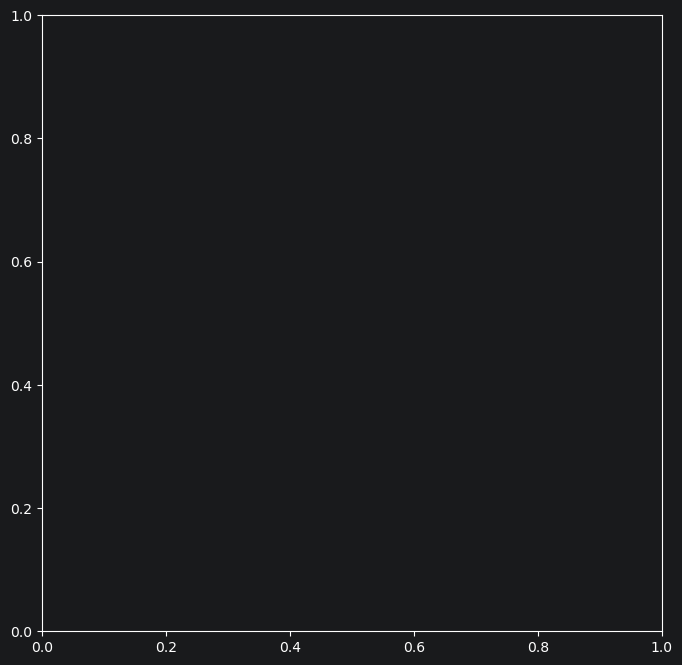

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

rgb.plot.imshow(
    ax=ax,
    robust=True
)

ax.set_title(str(arr.time.values[0]))